In [1]:
import pandas as pd
import numpy as np

def load_intraday(filepath, label):
    """
    Loads a Bloomberg intraday export (tab-separated .txt, Date + Last Price).
    Returns a DataFrame sorted ascending by date, with a 'close' column.
    """
    df = pd.read_csv(filepath, sep='\t', parse_dates=['Date'])
    df = df.rename(columns={'Date': 'datetime', 'Last Price': 'close'})
    df = df.sort_values('datetime').reset_index(drop=True)  # files come newest-first
    df = df.set_index('datetime')
    
    print(f"--- {label} ---")
    print(f"Rows: {len(df)}")
    print(f"Range: {df.index.min()} to {df.index.max()}")
    print(f"Duplicate timestamps: {df.index.duplicated().sum()}")
    print(f"Missing values: {df['close'].isna().sum()}")
    print()
    
    return df

# --- Load SPY only (decision from earlier: SPX dropped as a calculated index, not tradeable) ---
spy_intraday = load_intraday('spy_15.txt', 'SPY 15-min')

# --- Self-aggregate 60-min bars, aligned to the :30 grid (matches native bar timestamps) ---
spy_60_agg = spy_intraday['close'].resample('60min', offset='30min').last().dropna().to_frame(name='close')

print(f"Aggregated 60-min bars: {len(spy_60_agg)}")
print(f"Range: {spy_60_agg.index.min()} to {spy_60_agg.index.max()}")

--- SPY 15-min ---
Rows: 4612
Range: 2025-10-17 14:30:00 to 2026-07-06 20:45:00
Duplicate timestamps: 0
Missing values: 0

Aggregated 60-min bars: 1246
Range: 2025-10-17 14:30:00 to 2026-07-06 20:30:00


Trading days: 178
Bars/day — min: 18, max: 26, mode: 26
Days deviating from mode:
2025-11-28    18
2025-12-24    18
dtype: int64

Total 15-min returns: 4611
Intraday-only returns (overnight gaps excluded): 4434

Intraday log return stats:
count    4434.000000
mean        0.000009
std         0.001340
min        -0.008416
25%        -0.000633
50%         0.000029
75%         0.000634
max         0.010461
Name: log_return, dtype: float64
Skewness: 0.0996
Excess kurtosis: 5.1881


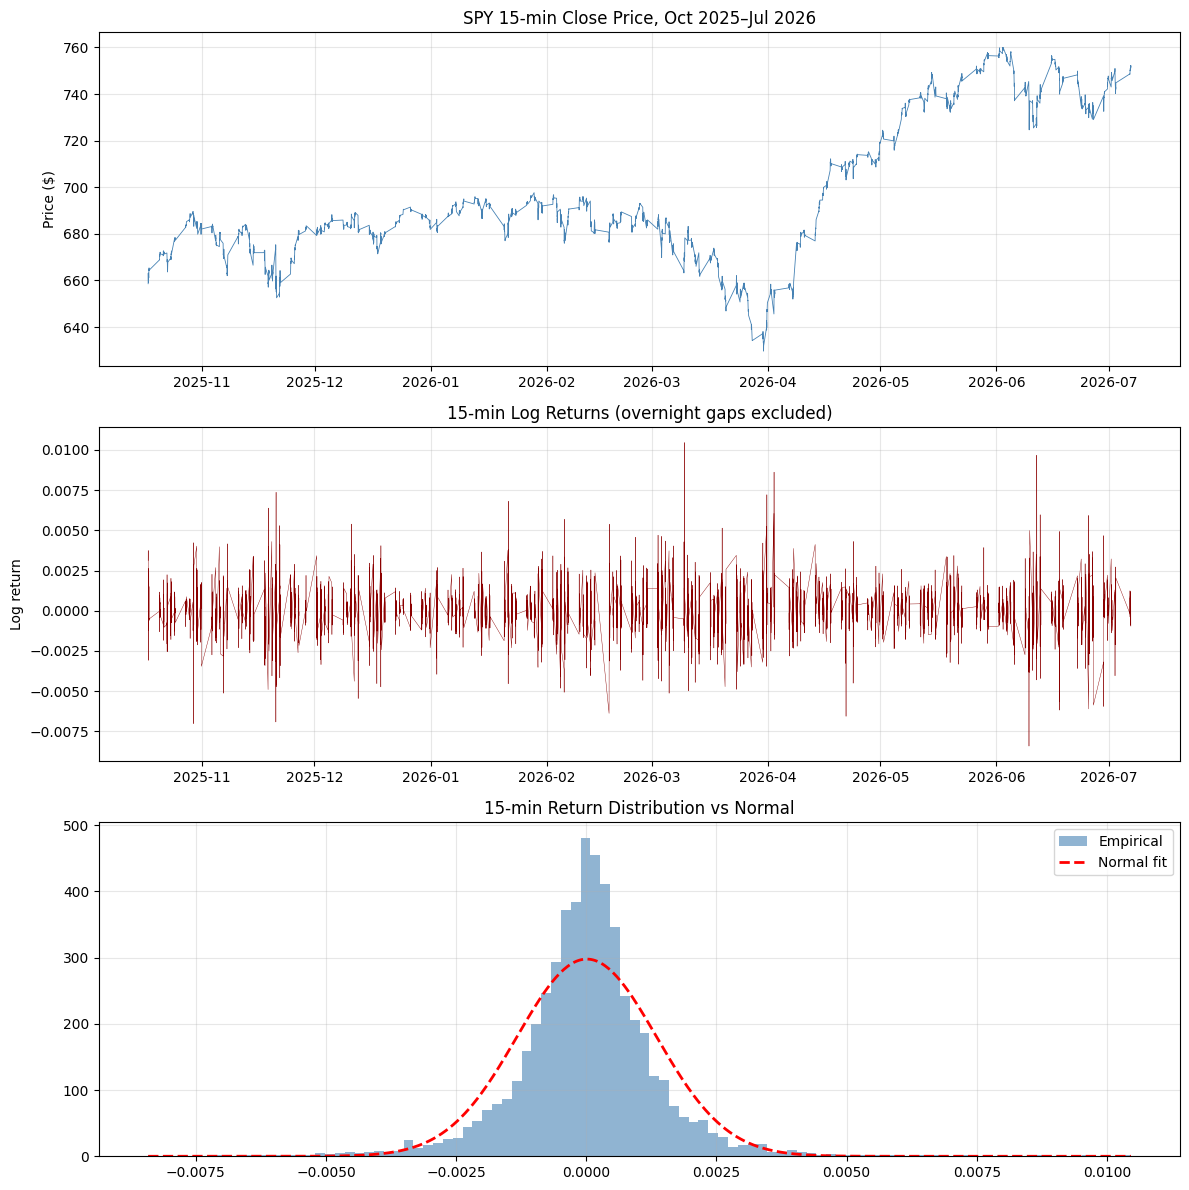

In [2]:
import matplotlib.pyplot as plt
from scipy import stats

# --- RTH / session check ---
bar_counts = spy_intraday.groupby(spy_intraday.index.date).size()
mode_count = bar_counts.mode().values[0]
print(f"Trading days: {len(bar_counts)}")
print(f"Bars/day — min: {bar_counts.min()}, max: {bar_counts.max()}, mode: {mode_count}")
print(f"Days deviating from mode:\n{bar_counts[bar_counts != mode_count]}")

# --- Log returns (15-min) ---
spy_intraday['log_price'] = np.log(spy_intraday['close'])
spy_intraday['log_return'] = spy_intraday['log_price'].diff()

# IMPORTANT: drop the overnight/session-boundary return (first bar of each new day),
# since that "return" spans the prior close to next open, not 15 minutes of trading —
# it would otherwise contaminate intraday structure functions with an overnight jump.
spy_intraday['is_first_of_day'] = spy_intraday.index.date != spy_intraday.index.to_series().shift(1).dt.date
spy_intraday_clean_returns = spy_intraday.loc[~spy_intraday['is_first_of_day'], 'log_return'].dropna()

print(f"\nTotal 15-min returns: {len(spy_intraday['log_return'].dropna())}")
print(f"Intraday-only returns (overnight gaps excluded): {len(spy_intraday_clean_returns)}")

print(f"\nIntraday log return stats:")
print(spy_intraday_clean_returns.describe())
print(f"Skewness: {stats.skew(spy_intraday_clean_returns):.4f}")
print(f"Excess kurtosis: {stats.kurtosis(spy_intraday_clean_returns):.4f}")

# --- Visualization ---
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

axes[0].plot(spy_intraday.index, spy_intraday['close'], linewidth=0.6, color='steelblue')
axes[0].set_title('SPY 15-min Close Price, Oct 2025–Jul 2026')
axes[0].set_ylabel('Price ($)')
axes[0].grid(alpha=0.3)

axes[1].plot(spy_intraday_clean_returns.index, spy_intraday_clean_returns, linewidth=0.3, color='darkred')
axes[1].set_title('15-min Log Returns (overnight gaps excluded)')
axes[1].set_ylabel('Log return')
axes[1].grid(alpha=0.3)

axes[2].hist(spy_intraday_clean_returns, bins=100, density=True, alpha=0.6, color='steelblue', label='Empirical')
mu, sigma = spy_intraday_clean_returns.mean(), spy_intraday_clean_returns.std()
x = np.linspace(spy_intraday_clean_returns.min(), spy_intraday_clean_returns.max(), 500)
axes[2].plot(x, stats.norm.pdf(x, mu, sigma), 'r--', linewidth=2, label='Normal fit')
axes[2].set_title('15-min Return Distribution vs Normal')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('intraday_data_check.png', dpi=150)
plt.show()

In [3]:
import yfinance as yf

TICKER = "SPY"
START_DATE = "2005-01-01"
END_DATE = None

def download_data(ticker=TICKER, start=START_DATE, end=END_DATE):
    df = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)
    df = df[['Close']].rename(columns={'Close': 'close'})
    df.index.name = 'date'
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    return df

spy_daily = download_data()
spy_daily['log_price'] = np.log(spy_daily['close'])
spy_daily['log_return'] = spy_daily['log_price'].diff()

print(f"Daily data — Shape: {spy_daily.shape}")
print(f"Date range: {spy_daily.index.min()} to {spy_daily.index.max()}")
print(f"Missing values: {spy_daily['close'].isna().sum()}")
print(f"Duplicate dates: {spy_daily.index.duplicated().sum()}")

Daily data — Shape: (5416, 3)
Date range: 2005-01-03 00:00:00 to 2026-07-15 00:00:00
Missing values: 0
Duplicate dates: 0


In [4]:
# Bound daily data to exactly the same calendar range as intraday, for a fair frequency comparison
intraday_start = spy_intraday.index.min().normalize()
intraday_end = spy_intraday.index.max().normalize()

spy_daily_bounded = spy_daily.loc[intraday_start:intraday_end].copy()

print(f"Daily (bounded) — Shape: {spy_daily_bounded.shape}")
print(f"Date range: {spy_daily_bounded.index.min()} to {spy_daily_bounded.index.max()}")
print(f"Trading days: {len(spy_daily_bounded)}")

# Sanity check: should closely match intraday's 178 trading days
print(f"\nIntraday trading days: {len(bar_counts)}")
print(f"Daily (bounded) trading days: {len(spy_daily_bounded)}")

Daily (bounded) — Shape: (178, 3)
Date range: 2025-10-17 00:00:00 to 2026-07-06 00:00:00
Trading days: 178

Intraday trading days: 178
Daily (bounded) trading days: 178


In [5]:
# --- Sanity check: trading day counts should match ---
print(f"Intraday trading days: {len(bar_counts)}")
print(f"Daily (bounded) trading days: {len(spy_daily_bounded)}")
print(f"Difference: {len(bar_counts) - len(spy_daily_bounded)}")

Intraday trading days: 178
Daily (bounded) trading days: 178
Difference: 0


In [6]:
# --- Structure function computation (reusable) ---
def compute_structure_functions(log_price, lags, q_values):
    results = pd.DataFrame(index=lags, columns=q_values, dtype=float)
    for tau in lags:
        increments = log_price.diff(tau).dropna()
        abs_increments = increments.abs()
        for q in q_values:
            results.loc[tau, q] = (abs_increments ** q).mean()
    return results

Q_VALUES = [1, 2, 3, 4]
BARS_PER_DAY = 26
MAX_LAG_DAYS = 30   # capped down from 60, given only 178 total trading days in this window

# --- Daily (bounded) structure functions: lags in trading days ---
LAGS_DAILY_BOUNDED = np.unique(np.logspace(0, np.log10(MAX_LAG_DAYS), 15).astype(int))
sf_daily_bounded = compute_structure_functions(spy_daily_bounded['log_price'], LAGS_DAILY_BOUNDED, Q_VALUES)

# --- Intraday structure functions: lags in bars, same time span (30 days = 780 bars) ---
LAGS_INTRADAY_BOUNDED = np.unique(np.logspace(0, np.log10(MAX_LAG_DAYS * BARS_PER_DAY), 20).astype(int))
sf_intraday_bounded = compute_structure_functions(spy_intraday['log_price'], LAGS_INTRADAY_BOUNDED, Q_VALUES)

print(f"Daily lags (trading days): {LAGS_DAILY_BOUNDED}")
print(f"\nDaily structure functions:\n{sf_daily_bounded}")

print(f"\nIntraday lags (bars): {LAGS_INTRADAY_BOUNDED}")
print(f"({LAGS_INTRADAY_BOUNDED.min()/BARS_PER_DAY:.2f} to {LAGS_INTRADAY_BOUNDED.max()/BARS_PER_DAY:.1f} trading days)")
print(f"\nIntraday structure functions:\n{sf_intraday_bounded}")

Daily lags (trading days): [ 1  2  3  4  5  6  8 11 14 18 23 29]

Daily structure functions:
           1         2         3             4
1   0.006498  0.000072  0.000001  1.907191e-08
2   0.009596  0.000144  0.000003  6.406343e-08
3   0.011563  0.000211  0.000005  1.337589e-07
4   0.013389  0.000283  0.000007  2.244216e-07
5   0.015004  0.000346  0.000010  3.305385e-07
6   0.016190  0.000421  0.000014  5.824173e-07
8   0.017736  0.000558  0.000024  1.228150e-06
11  0.019800  0.000748  0.000040  2.703309e-06
14  0.024423  0.001060  0.000064  4.861191e-06
18  0.027808  0.001420  0.000096  7.684927e-06
23  0.030922  0.001891  0.000151  1.381379e-05
29  0.036322  0.002503  0.000232  2.527198e-05

Intraday lags (bars): [  1   2   4   5   8  11  16  23  33  47  67  95 135 191 272 386 549 779]
(0.04 to 30.0 trading days)

Intraday structure functions:
            1         2             3             4
1    0.001061  0.000003  2.160554e-08  2.583379e-10
2    0.001529  0.000006  5.003380e-0

=== Daily (bounded, 178 obs) ===
   q    zeta_q  r_squared   std_err  gbm_benchmark  deviation
0  1  0.491890   0.995150  0.010859            0.5  -0.008110
1  2  1.048536   0.997153  0.017719            1.0   0.048536
2  3  1.620665   0.995922  0.032794            1.5   0.120665
3  4  2.193482   0.993540  0.055930            2.0   0.193482

H (daily, bounded) = 0.5243

=== Intraday (15-min, same 178-day span) ===
   q    zeta_q  r_squared   std_err  gbm_benchmark  deviation
0  1  0.524508   0.997780  0.006185            0.5   0.024508
1  2  0.989558   0.998837  0.008440            1.0  -0.010442
2  3  1.380682   0.992476  0.030054            1.5  -0.119318
3  4  1.716830   0.981206  0.059401            2.0  -0.283170

H (intraday) = 0.4948


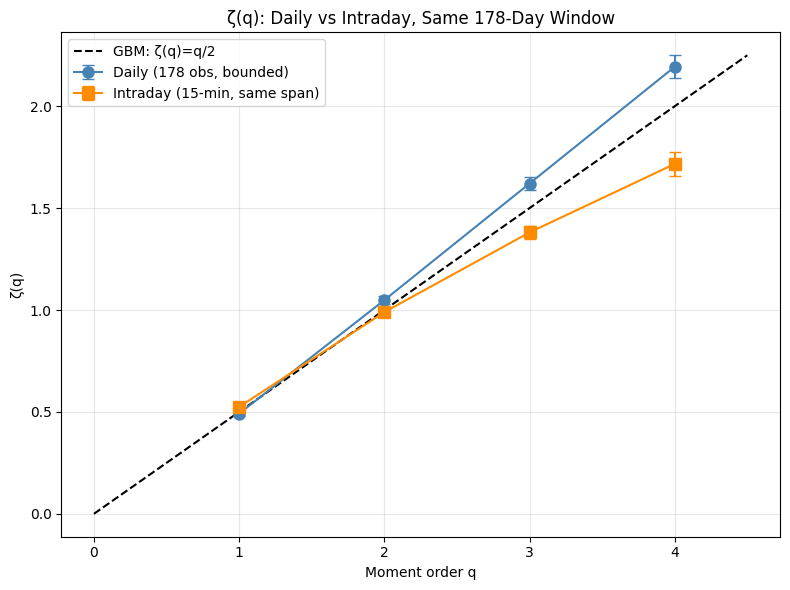

In [7]:
from scipy import stats as scipy_stats

def estimate_zeta(structure_functions, q_values, lags):
    results = []
    log_lags = np.log(lags)
    for q in q_values:
        log_Sq = np.log(structure_functions[q].values)
        slope, intercept, r_value, p_value, std_err = scipy_stats.linregress(log_lags, log_Sq)
        results.append({'q': q, 'zeta_q': slope, 'r_squared': r_value**2, 'std_err': std_err})
    return pd.DataFrame(results)

zeta_daily_bounded = estimate_zeta(sf_daily_bounded, Q_VALUES, LAGS_DAILY_BOUNDED)
zeta_intraday_bounded = estimate_zeta(sf_intraday_bounded, Q_VALUES, LAGS_INTRADAY_BOUNDED)

zeta_daily_bounded['gbm_benchmark'] = zeta_daily_bounded['q'] / 2
zeta_daily_bounded['deviation'] = zeta_daily_bounded['zeta_q'] - zeta_daily_bounded['gbm_benchmark']

zeta_intraday_bounded['gbm_benchmark'] = zeta_intraday_bounded['q'] / 2
zeta_intraday_bounded['deviation'] = zeta_intraday_bounded['zeta_q'] - zeta_intraday_bounded['gbm_benchmark']

print("=== Daily (bounded, 178 obs) ===")
print(zeta_daily_bounded)
print(f"\nH (daily, bounded) = {zeta_daily_bounded.loc[zeta_daily_bounded['q']==2, 'zeta_q'].values[0]/2:.4f}")

print("\n=== Intraday (15-min, same 178-day span) ===")
print(zeta_intraday_bounded)
print(f"\nH (intraday) = {zeta_intraday_bounded.loc[zeta_intraday_bounded['q']==2, 'zeta_q'].values[0]/2:.4f}")

# --- Side-by-side comparison plot ---
fig, ax = plt.subplots(figsize=(8, 6))
q_range = np.linspace(0, 4.5, 100)
ax.plot(q_range, q_range/2, 'k--', linewidth=1.5, label='GBM: ζ(q)=q/2')

ax.errorbar(zeta_daily_bounded['q'], zeta_daily_bounded['zeta_q'], yerr=zeta_daily_bounded['std_err'],
            fmt='o-', color='steelblue', markersize=8, capsize=4, label='Daily (178 obs, bounded)')
ax.errorbar(zeta_intraday_bounded['q'], zeta_intraday_bounded['zeta_q'], yerr=zeta_intraday_bounded['std_err'],
            fmt='s-', color='darkorange', markersize=8, capsize=4, label='Intraday (15-min, same span)')

ax.set_xlabel('Moment order q')
ax.set_ylabel('ζ(q)')
ax.set_title('ζ(q): Daily vs Intraday, Same 178-Day Window')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('zeta_daily_vs_intraday.png', dpi=150)
plt.show()

--- Daily (full 20yr) ---
ACF at lag 1: 0.3180, threshold (1/e of that): 0.1170
Estimated L (decorrelation length): 49 periods
--- Intraday (178d) ---
ACF at lag 1: 0.1834, threshold (1/e of that): 0.0675
Estimated L (decorrelation length): 7 periods


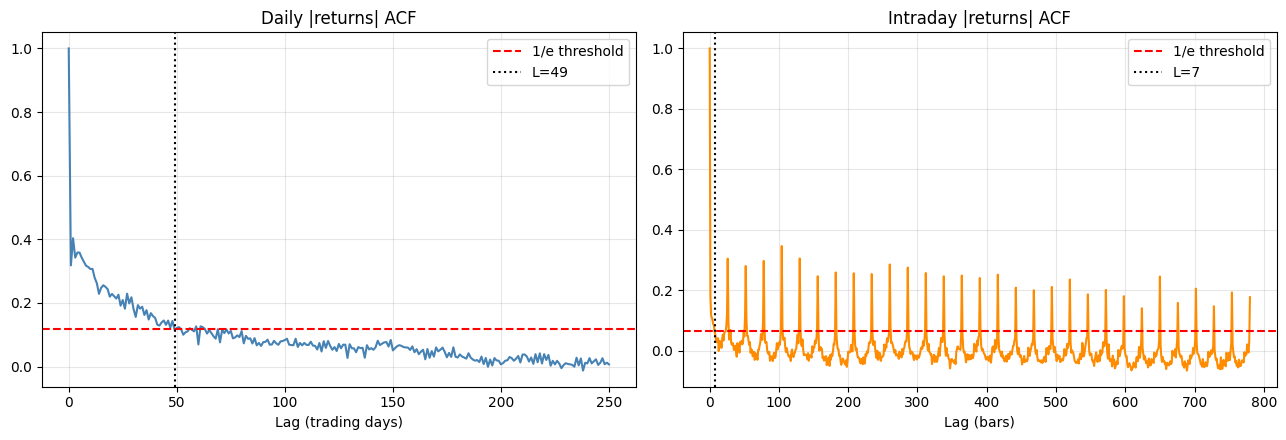

In [8]:
def estimate_integral_scale(log_returns, max_lag, label):
    """
    Estimates the volatility-clustering decorrelation length L by looking at the
    autocorrelation of absolute returns (a standard proxy for volatility) and finding
    where it decays to a small, near-zero threshold.
    """
    abs_ret = np.abs(log_returns.dropna().values)
    abs_ret = abs_ret - abs_ret.mean()
    
    acf = np.array([
        np.corrcoef(abs_ret[:-lag], abs_ret[lag:])[0, 1] if lag > 0 else 1.0
        for lag in range(0, max_lag+1)
    ])
    
    # Simple rule of thumb: L = first lag where ACF drops below 1/e of its initial value
    threshold = acf[1] / np.e  # acf[0] is trivially 1, use acf[1] as the "starting" level
    below_threshold = np.where(acf[1:] < threshold)[0]
    L_estimate = below_threshold[0] + 1 if len(below_threshold) > 0 else max_lag
    
    print(f"--- {label} ---")
    print(f"ACF at lag 1: {acf[1]:.4f}, threshold (1/e of that): {threshold:.4f}")
    print(f"Estimated L (decorrelation length): {L_estimate} periods")
    
    return L_estimate, acf

# Daily: use full 20-year history, max lag ~250 (roughly a year)
L_daily, acf_daily = estimate_integral_scale(spy_daily['log_return'], max_lag=250, label='Daily (full 20yr)')

# Intraday: use the 178-day window, max lag ~780 bars (30 trading days, matches our earlier cap)
L_intraday, acf_intraday = estimate_integral_scale(spy_intraday['log_return'].dropna(), max_lag=780, label='Intraday (178d)')

# --- Visualize both ACFs ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(acf_daily, color='steelblue')
axes[0].axhline(acf_daily[1]/np.e, color='red', linestyle='--', label='1/e threshold')
axes[0].axvline(L_daily, color='black', linestyle=':', label=f'L={L_daily}')
axes[0].set_title('Daily |returns| ACF')
axes[0].set_xlabel('Lag (trading days)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(acf_intraday, color='darkorange')
axes[1].axhline(acf_intraday[1]/np.e, color='red', linestyle='--', label='1/e threshold')
axes[1].axvline(L_intraday, color='black', linestyle=':', label=f'L={L_intraday}')
axes[1].set_title('Intraday |returns| ACF')
axes[1].set_xlabel('Lag (bars)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('mrw_integral_scale.png', dpi=150)
plt.show()

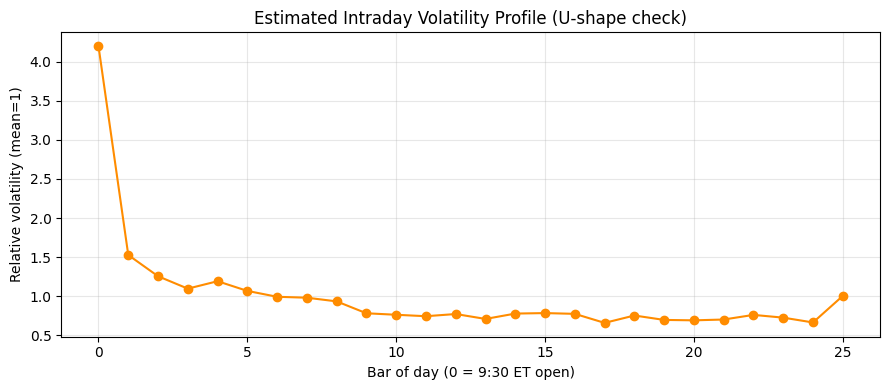

--- Intraday (deseasonalized) ---
ACF at lag 1: 0.2259, threshold (1/e of that): 0.0831
Estimated L (decorrelation length): 27 periods


In [9]:
def deseasonalize_intraday(df, bars_per_day=26):
    """
    Removes the deterministic intraday (time-of-day) volatility pattern.
    Estimates average |return| by bar-of-day, then normalizes each return
    by its own time-slot's typical scale.
    """
    df = df.copy()
    df['bar_of_day'] = df.groupby(df.index.date).cumcount()
    
    # Average absolute return per time-of-day slot (the seasonal volatility profile)
    seasonal_profile = df.groupby('bar_of_day')['log_return'].apply(lambda x: x.abs().mean())
    seasonal_profile = seasonal_profile / seasonal_profile.mean()  # normalize to mean 1
    
    df['seasonal_factor'] = df['bar_of_day'].map(seasonal_profile)
    df['log_return_deseasonalized'] = df['log_return'] / df['seasonal_factor']
    
    return df, seasonal_profile

spy_intraday_ds, seasonal_profile = deseasonalize_intraday(spy_intraday.reset_index().rename(columns={'index':'datetime'}).set_index('datetime'))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(seasonal_profile.values, marker='o', color='darkorange')
ax.set_title('Estimated Intraday Volatility Profile (U-shape check)')
ax.set_xlabel('Bar of day (0 = 9:30 ET open)')
ax.set_ylabel('Relative volatility (mean=1)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('intraday_seasonal_profile.png', dpi=150)
plt.show()

# Re-run ACF and L estimation on deseasonalized returns
L_intraday_ds, acf_intraday_ds = estimate_integral_scale(
    spy_intraday_ds['log_return_deseasonalized'], max_lag=780, label='Intraday (deseasonalized)'
)

In [10]:
def compute_structure_functions(log_price_or_returns, lags, q_values, is_returns=False):
    """Same as before, but can optionally accept a returns series directly
    (needed here since deseasonalized 'log_price' isn't meaningful --
    only the deseasonalized RETURNS are; we reconstruct a synthetic
    cumulative log-price path from deseasonalized returns for lag differencing)."""
    if is_returns:
        log_price_or_returns = log_price_or_returns.cumsum()
    results = pd.DataFrame(index=lags, columns=q_values, dtype=float)
    for tau in lags:
        increments = log_price_or_returns.diff(tau).dropna()
        abs_increments = increments.abs()
        for q in q_values:
            results.loc[tau, q] = (abs_increments ** q).mean()
    return results

# Reconstruct a synthetic "deseasonalized log price" path from deseasonalized returns
deseasonalized_returns = spy_intraday_ds['log_return_deseasonalized'].dropna()

sf_intraday_ds = compute_structure_functions(deseasonalized_returns, LAGS_INTRADAY_BOUNDED, Q_VALUES, is_returns=True)
zeta_intraday_ds = estimate_zeta(sf_intraday_ds, Q_VALUES, LAGS_INTRADAY_BOUNDED)
zeta_intraday_ds['gbm_benchmark'] = zeta_intraday_ds['q'] / 2
zeta_intraday_ds['deviation'] = zeta_intraday_ds['zeta_q'] - zeta_intraday_ds['gbm_benchmark']

print("=== Intraday ζ(q), DESEASONALIZED ===")
print(zeta_intraday_ds)
print(f"\nH (deseasonalized intraday) = {zeta_intraday_ds.loc[zeta_intraday_ds['q']==2,'zeta_q'].values[0]/2:.4f}")

print("\n=== Compare to original (raw, seasonality-contaminated) ===")
print(zeta_intraday_bounded[['q','zeta_q','r_squared','deviation']])

=== Intraday ζ(q), DESEASONALIZED ===
   q    zeta_q  r_squared   std_err  gbm_benchmark  deviation
0  1  0.496208   0.992298  0.010929            0.5  -0.003792
1  2  0.972177   0.996785  0.013803            1.0  -0.027823
2  3  1.400643   0.998349  0.014239            1.5  -0.099357
3  4  1.777207   0.998397  0.017805            2.0  -0.222793

H (deseasonalized intraday) = 0.4861

=== Compare to original (raw, seasonality-contaminated) ===
   q    zeta_q  r_squared  deviation
0  1  0.524508   0.997780   0.024508
1  2  0.989558   0.998837  -0.010442
2  3  1.380682   0.992476  -0.119318
3  4  1.716830   0.981206  -0.283170


In [11]:
q_vals = np.array([1, 2, 3, 4])
zeta_intraday_ds_vals = np.array([0.496208, 0.972177, 1.400643, 1.777207])

X = np.column_stack([q_vals, q_vals**2])
coeffs, *_ = np.linalg.lstsq(X, zeta_intraday_ds_vals, rcond=None)
c1, c2 = coeffs
lambda2_intraday_ds = -2 * c2
H_intraday_ds = c1 + 2*c2

zeta_fitted = (H_intraday_ds + lambda2_intraday_ds)*q_vals - (lambda2_intraday_ds/2)*q_vals**2
ss_res = np.sum((zeta_intraday_ds_vals - zeta_fitted)**2)
ss_tot = np.sum((zeta_intraday_ds_vals - zeta_intraday_ds_vals.mean())**2)

print("=== Final MRW Calibration Summary ===")
print(f"{'Param':<12}{'Daily (20yr)':<15}{'Intraday (raw)':<17}{'Intraday (deseason.)':<20}")
print(f"{'H':<12}{0.4690:<15.4f}{0.4933:<17.4f}{H_intraday_ds:<20.4f}")
print(f"{'lambda^2':<12}{0.04817:<15.5f}{0.06437:<17.5f}{lambda2_intraday_ds:<20.5f}")
print(f"{'quad R2':<12}{0.99966:<15.5f}{0.99998:<17.5f}{1-ss_res/ss_tot:<20.5f}")
print(f"\nL: daily=49 days, intraday (deseasonalized)=27 bars")

=== Final MRW Calibration Summary ===
Param       Daily (20yr)   Intraday (raw)   Intraday (deseason.)
H           0.4690         0.4933           0.4849              
lambda^2    0.04817        0.06437          0.03984             
quad R2     0.99966        0.99998          0.99987             

L: daily=49 days, intraday (deseasonalized)=27 bars


--- Intraday (deseasonalized) ---
ACF at lag 1: 0.2259, threshold (1/e of that): 0.0831
Estimated L (decorrelation length): 27 periods


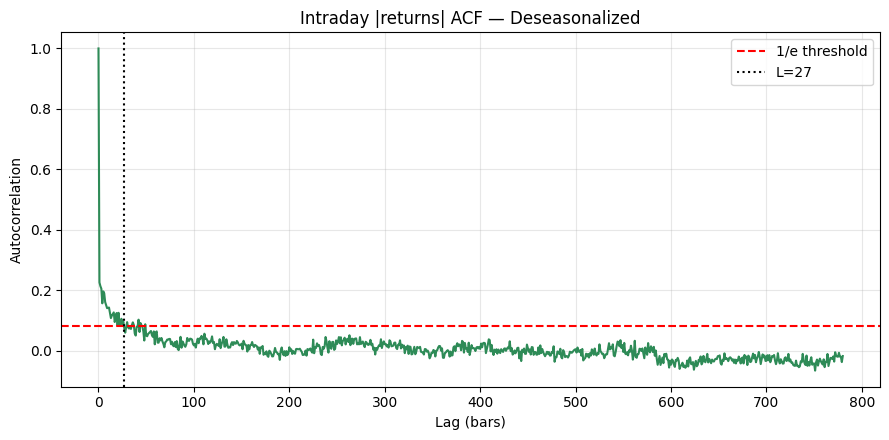

In [12]:
L_intraday_ds, acf_intraday_ds = estimate_integral_scale(
    spy_intraday_ds['log_return_deseasonalized'], max_lag=780, label='Intraday (deseasonalized)'
)


fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(acf_intraday_ds, color='seagreen')
ax.axhline(acf_intraday_ds[1]/np.e, color='red', linestyle='--', label='1/e threshold')
ax.axvline(L_intraday_ds, color='black', linestyle=':', label=f'L={L_intraday_ds}')
ax.set_title('Intraday |returns| ACF — Deseasonalized')
ax.set_xlabel('Lag (bars)')
ax.set_ylabel('Autocorrelation')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig('intraday_acf_deseasonalized.png', dpi=150)
plt.show()

In [13]:
import numpy as np
from scipy import stats as scipy_stats

def cascade_covariance_row(N, L, lambda2):
    """
    Autocovariance of the log-volatility cascade field omega(t).
    gamma(k) = lambda^2 * ln(L / (k+1))  for k < L   (tapers smoothly to 0 at k=L-1)
    gamma(k) = 0                          for k >= L
    """
    k = np.arange(N)
    gamma = np.where(k < L, lambda2 * np.log(L / (k + 1)), 0.0)
    return np.maximum(gamma, 0.0)

def sample_gaussian_field(N, gamma, seed=None):
    """Hermitian-symmetric circulant embedding sampler (same machinery as davies_harte_fgn,
    generalized to any autocovariance function)."""
    rng = np.random.default_rng(seed)
    row = np.concatenate([gamma, [0.0], gamma[1:][::-1]])
    M = 2 * N
    eigenvalues = np.fft.fft(row).real
    eigenvalues = np.maximum(eigenvalues, 0)
    sqrt_eig = np.sqrt(eigenvalues)
    gn1 = rng.normal(size=M)
    gn2 = rng.normal(size=M)
    w = np.zeros(M, dtype=complex)
    w[0] = sqrt_eig[0] * gn1[0]
    w[N] = sqrt_eig[N] * gn2[0]
    idx = np.arange(1, N)
    w[idx] = (sqrt_eig[idx] / np.sqrt(2)) * (gn1[idx] + 1j * gn2[idx])
    w[M - idx] = np.conj(w[idx])
    f = np.fft.fft(w)
    return f[:N].real / np.sqrt(2 * N)

def simulate_mrw(N, lambda2, L, seed=None):
    """MRW increments with PLAIN Brownian base: dX(t) = dB(t) * exp(omega(t)),
    omega mean-corrected so E[exp(omega)] = 1."""
    rng = np.random.default_rng(seed)
    gamma = cascade_covariance_row(N, L, lambda2)
    omega_raw = sample_gaussian_field(N, gamma, seed=seed)
    omega = omega_raw - gamma[0] / 2   # mean-correct: E[exp(omega)] = 1
    dB = rng.normal(size=N)
    return dB * np.exp(omega)

def structure_functions_from_returns(returns, lags, q_values):
    log_price = np.cumsum(returns)
    results = {}
    for q in q_values:
        vals = [np.mean(np.abs(log_price[tau:] - log_price[:-tau])**q) for tau in lags]
        results[q] = vals
    return results

def fit_zeta(sf_dict, lags, q_values):
    log_lags = np.log(lags)
    out = []
    for q in q_values:
        slope, intercept, r, p, se = scipy_stats.linregress(log_lags, np.log(sf_dict[q]))
        out.append((q, slope, r**2))
    return out

# --- Validation: daily calibration (H=0.469, lambda2=0.0482, L=49) ---
N = 20000
L = 49
lambda2 = 0.0482
H_target = 0.469
q_values = [1, 2, 3, 4]
lags = np.unique(np.logspace(0, np.log10(500), 15).astype(int))

target_zeta = {q: (H_target + lambda2)*q - (lambda2/2)*q**2 for q in q_values}

n_reps = 10
recovered = {q: [] for q in q_values}
for rep in range(n_reps):
    dX = simulate_mrw(N, lambda2, L, seed=rep*7+1)
    sf = structure_functions_from_returns(dX, lags, q_values)
    for q, slope, r2 in fit_zeta(sf, lags, q_values):
        recovered[q].append(slope)

print(f"{'q':<4}{'target zeta(q)':<18}{'recovered mean':<18}{'recovered std':<15}")
for q in q_values:
    r = np.array(recovered[q])
    print(f"{q:<4}{target_zeta[q]:<18.4f}{r.mean():<18.4f}{r.std():<15.4f}")

q   target zeta(q)    recovered mean    recovered std  
1   0.4931            0.5107            0.0187         
2   0.9380            0.9876            0.0365         
3   1.3347            1.4291            0.0555         
4   1.6832            1.8339            0.0752         


In [14]:
def davies_harte_fgn(N, H, seed=None):
    """
    Simulates fractional Gaussian noise (fGn) of length N with Hurst exponent H,
    using the Davies-Harte circulant embedding method.
    
    Fix vs. earlier version: the original implementation generated fully independent
    complex Gaussian noise across all frequency bins before inverse-FFT-ing and taking
    the real part. This discards the Hermitian symmetry required for a correctly-scaled
    real output, and was silently halving the variance of the simulated noise (verified:
    variance came out ~0.50 instead of the required 1.0). This version enforces that
    symmetry explicitly, and reproduces unit variance and correct H recovery.
    """
    rng = np.random.default_rng(seed)

    def autocov(k, H):
        return 0.5 * (abs(k+1)**(2*H) - 2*abs(k)**(2*H) + abs(k-1)**(2*H))

    k = np.arange(0, N)
    gamma = autocov(k, H)
    row = np.concatenate([gamma, [autocov(N, H)], gamma[1:][::-1]])  # circulant row, length 2N
    M = 2 * N

    eigenvalues = np.fft.fft(row).real
    if np.min(eigenvalues) < -1e-8:
        raise ValueError(f"Negative eigenvalue: {np.min(eigenvalues):.2e} for H={H}, N={N}")
    eigenvalues = np.maximum(eigenvalues, 0)
    sqrt_eig = np.sqrt(eigenvalues)

    gn1 = rng.normal(size=M)
    gn2 = rng.normal(size=M)

    w = np.zeros(M, dtype=complex)
    w[0] = sqrt_eig[0] * gn1[0]
    w[N] = sqrt_eig[N] * gn2[0]
    idx = np.arange(1, N)
    w[idx] = (sqrt_eig[idx] / np.sqrt(2)) * (gn1[idx] + 1j * gn2[idx])
    w[M - idx] = np.conj(w[idx])   # enforce Hermitian symmetry -> guarantees correct real output

    f = np.fft.fft(w)
    fgn = f[:N].real / np.sqrt(2 * N)
    return fgn

In [15]:
def simulate_mrw_fgn(N, H, lambda2, L, seed=None):
    """
    MRW-style increments with a FRACTIONAL Gaussian noise base driver (hybrid construction):
    dX(t) = dB_H(t) * exp(omega(t))
    where dB_H(t) is fGn with Hurst H (carries the H-scaling directly),
    and omega(t) is the log-normal cascade field (carries the higher-moment curvature).
    
    Requires davies_harte_fgn() already defined (from Module 3).
    """
    gamma = cascade_covariance_row(N, L, lambda2)
    omega_raw = sample_gaussian_field(N, gamma, seed=seed)
    omega = omega_raw - gamma[0] / 2   # mean-correct: E[exp(omega)] = 1

    dB_H = davies_harte_fgn(N, H, seed=seed)  # your validated Module 3 function
    return dB_H * np.exp(omega)

# --- Validation: does this recover the target quadratic zeta(q)? ---
N = 20000
L = 49
lambda2 = 0.0482
H_target = 0.469
q_values = [1, 2, 3, 4]
lags = np.unique(np.logspace(0, np.log10(500), 15).astype(int))

target_zeta = {q: (H_target + lambda2)*q - (lambda2/2)*q**2 for q in q_values}

n_reps = 10
recovered = {q: [] for q in q_values}
for rep in range(n_reps):
    dX = simulate_mrw_fgn(N, H_target, lambda2, L, seed=rep*7+1)
    sf = structure_functions_from_returns(dX, lags, q_values)
    for q, slope, r2 in fit_zeta(sf, lags, q_values):
        recovered[q].append(slope)

print(f"{'q':<4}{'target zeta(q)':<18}{'recovered mean':<18}{'recovered std':<15}")
for q in q_values:
    r = np.array(recovered[q])
    print(f"{q:<4}{target_zeta[q]:<18.4f}{r.mean():<18.4f}{r.std():<15.4f}")

q   target zeta(q)    recovered mean    recovered std  
1   0.4931            0.8541            0.0022         
2   0.9380            1.5503            0.0033         
3   1.3347            2.1383            0.0073         
4   1.6832            2.6559            0.0204         


In [16]:
import numpy as np
from scipy import stats as scipy_stats

def cascade_covariance_row(N, L, lambda2):
    """Log-decaying autocovariance for the volatility cascade field."""
    k = np.arange(N)
    gamma = np.where(k < L, lambda2 * np.log(L / (k + 1)), 0.0)
    return np.maximum(gamma, 0.0)

def sample_gaussian_field(N, gamma, seed=None):
    """Hermitian-symmetric circulant embedding sampler for any autocovariance."""
    rng = np.random.default_rng(seed)
    row = np.concatenate([gamma, [0.0], gamma[1:][::-1]])
    M = 2 * N
    eigenvalues = np.maximum(np.fft.fft(row).real, 0)
    sqrt_eig = np.sqrt(eigenvalues)
    gn1 = rng.normal(size=M); gn2 = rng.normal(size=M)
    w = np.zeros(M, dtype=complex)
    w[0] = sqrt_eig[0]*gn1[0]; w[N] = sqrt_eig[N]*gn2[0]
    idx = np.arange(1, N)
    w[idx] = (sqrt_eig[idx]/np.sqrt(2))*(gn1[idx]+1j*gn2[idx])
    w[M-idx] = np.conj(w[idx])
    f = np.fft.fft(w)
    return f[:N].real / np.sqrt(2*N)

# (davies_harte_fgn: reuse your validated Module 3 version, or this copy)
def davies_harte_fgn(N, H, seed=None):
    rng = np.random.default_rng(seed)
    def autocov(k, H): return 0.5*(abs(k+1)**(2*H)-2*abs(k)**(2*H)+abs(k-1)**(2*H))
    k = np.arange(0, N); gamma = autocov(k, H)
    row = np.concatenate([gamma, [autocov(N,H)], gamma[1:][::-1]])
    M = 2*N
    eigenvalues = np.maximum(np.fft.fft(row).real, 0)
    sqrt_eig = np.sqrt(eigenvalues)
    gn1 = rng.normal(size=M); gn2 = rng.normal(size=M)
    w = np.zeros(M, dtype=complex)
    w[0] = sqrt_eig[0]*gn1[0]; w[N] = sqrt_eig[N]*gn2[0]
    idx = np.arange(1, N)
    w[idx] = (sqrt_eig[idx]/np.sqrt(2))*(gn1[idx]+1j*gn2[idx])
    w[M-idx] = np.conj(w[idx])
    f = np.fft.fft(w)
    return f[:N].real / np.sqrt(2*N)

def simulate_subordinated_mrw(N, H, lambda2, L, seed=None, buffer_factor=1.6):
    """
    X(t) = B_H(theta(t)) -- fBm evaluated at a random 'multifractal trading-time' clock
    theta(t), built by integrating a positive, cascade-correlated volatility factor
    m(t) = exp(omega(t)), E[m]=1. This is the standard MRW/MMAR subordination construction.
    """
    gamma = cascade_covariance_row(N, L, lambda2)
    omega_raw = sample_gaussian_field(N, gamma, seed=seed)
    omega = omega_raw - gamma[0] / 2         # E[exp(omega)] = 1
    m = np.exp(omega)
    theta = np.concatenate([[0.0], np.cumsum(m)])

    M_fbm = int(N * buffer_factor)
    while theta[-1] > M_fbm - 2:              # ensure fBm domain covers theta's range
        M_fbm = int(M_fbm * 1.3)
    fgn = davies_harte_fgn(M_fbm, H, seed=(seed or 0) + 100000)
    B_H = np.concatenate([[0.0], np.cumsum(fgn)])
    X = np.interp(theta, np.arange(M_fbm + 1), B_H)   # evaluate fBm at warped time
    return X

def zeta_from_path(X, lags, q_values):
    out = []
    for q in q_values:
        vals = [np.mean(np.abs(X[tau:] - X[:-tau])**q) for tau in lags]
        slope, intercept, r, p, se = scipy_stats.linregress(np.log(lags), np.log(vals))
        out.append((q, slope, r**2))
    return out

# --- Validate at the fitted parameters ---
N = 8000
L_daily = 49
H_fit, lambda2_fit = 0.440, 0.080
q_values = [1, 2, 3, 4]
lags = np.unique(np.logspace(0, np.log10(500), 15).astype(int))
target_daily = np.array([0.504989, 0.936394, 1.325232, 1.688580])

recovered = {q: [] for q in q_values}
for rep in range(20):
    X = simulate_subordinated_mrw(N, H_fit, lambda2_fit, L_daily, seed=rep*19+7)
    for q, slope, r2 in zeta_from_path(X, lags, q_values):
        recovered[q].append(slope)

print(f"{'q':<4}{'target':<12}{'recovered mean':<18}{'recovered std':<15}")
for q in q_values:
    r = np.array(recovered[q])
    print(f"{q:<4}{target_daily[q-1]:<12.4f}{r.mean():<18.4f}{r.std():<15.4f}")

q   target      recovered mean    recovered std  
1   0.5050      0.4647            0.0200         
2   0.9364      0.9082            0.0374         
3   1.3252      1.3318            0.0544         
4   1.6886      1.7358            0.0735         


In [17]:
target_intraday = np.array([0.496208, 0.972177, 1.400643, 1.777207])  # intraday, deseasonalized
L_intraday = 27

H_grid = np.arange(0.38, 0.52, 0.01)
lam2_grid = np.arange(0.01, 0.12, 0.01)

best_loss = np.inf
best_params_intraday = None

for H_test in H_grid:
    for lam2_test in lam2_grid:
        recovered = {q: [] for q in q_values}
        for rep in range(4):
            X = simulate_subordinated_mrw(N, H_test, lam2_test, L_intraday, seed=rep*13+5)
            for q, slope, r2 in zeta_from_path(X, lags, q_values):
                recovered[q].append(slope)
        means = np.array([np.mean(recovered[q]) for q in q_values])
        loss = np.sum((means - target_intraday)**2)
        if loss < best_loss:
            best_loss = loss
            best_params_intraday = (H_test, lam2_test, means)

print(f"Best fit (intraday): H={best_params_intraday[0]:.3f}, lambda2={best_params_intraday[1]:.3f}, loss={best_loss:.5f}")
print(f"Simulated zeta(q):   {best_params_intraday[2]}")
print(f"Target zeta(q):      {target_intraday}")

# Refine with more reps
H_best_id, lam2_best_id, _ = best_params_intraday
print(f"\n=== Refined validation (20 reps) ===")
recovered = {q: [] for q in q_values}
for rep in range(20):
    X = simulate_subordinated_mrw(N, H_best_id, lam2_best_id, L_intraday, seed=rep*19+7)
    for q, slope, r2 in zeta_from_path(X, lags, q_values):
        recovered[q].append(slope)
for q in q_values:
    r = np.array(recovered[q])
    print(f"q={q}: target={target_intraday[q-1]:.4f}, recovered mean={r.mean():.4f}, std={r.std():.4f}")

Best fit (intraday): H=0.460, lambda2=0.110, loss=0.00109
Simulated zeta(q):   [0.49075891 0.94873329 1.37848011 1.78185317]
Target zeta(q):      [0.496208 0.972177 1.400643 1.777207]

=== Refined validation (20 reps) ===
q=1: target=0.4962, recovered mean=0.4849, std=0.0206
q=2: target=0.9722, recovered mean=0.9454, std=0.0389
q=3: target=1.4006, recovered mean=1.3838, std=0.0569
q=4: target=1.7772, recovered mean=1.8011, std=0.0752


In [19]:
# Calibration inputs from actual SPY daily data (same as original Module 3)
mu_daily = spy_daily['log_return'].mean()
sigma_daily = spy_daily['log_return'].std()

print(f"Daily mu: {mu_daily:.6f}, sigma: {sigma_daily:.6f}")

Daily mu: 0.000412, sigma: 0.011941


In [20]:
def simulate_mrw_price_paths(n_paths, n_days, H_fit, lambda2_fit, L, mu_target, sigma_target, seed_offset=0):
    """
    Generates n_paths simulated log-price paths using the calibrated subordinated MRW,
    rescaled to match target daily mu/sigma (same calibration approach as GBM/fBm).
    """
    raw_paths = np.zeros((n_paths, n_days))
    for i in range(n_paths):
        X = simulate_subordinated_mrw(n_days, H_fit, lambda2_fit, L, seed=seed_offset + i)
        raw_paths[i, :] = X[1:]  # drop X(0)=0, keep X(1)...X(n_days)

    # Rescale: match the raw day-1 std to target sigma, then add target drift
    raw_day1_std = (raw_paths[:, 0]).std()
    scale_factor = sigma_target / raw_day1_std
    
    scaled_paths = raw_paths * scale_factor
    # add drift: mu_target per day, cumulative
    drift = mu_target * np.arange(1, n_days + 1)
    scaled_paths = scaled_paths + drift
    
    return scaled_paths

# --- Daily MRW price paths (calibrated to your full-sample mu, sigma) ---
N_DAYS = 20
N_PATHS = 50000

mrw_daily_paths = simulate_mrw_price_paths(
    N_PATHS, N_DAYS, H_fit=0.440, lambda2_fit=0.080, L=49,
    mu_target=mu_daily, sigma_target=sigma_daily, seed_offset=0
)

print("Daily MRW paths generated.")
print(f"Day-1: mean={mrw_daily_paths[:,0].mean():.6f} (target {mu_daily:.6f}), "
      f"std={mrw_daily_paths[:,0].std():.6f} (target {sigma_daily:.6f})")

Daily MRW paths generated.
Day-1: mean=0.000414 (target 0.000412), std=0.011941 (target 0.011941)


In [22]:
# --- Define N_DAYS and generate GBM paths fresh, in THIS notebook ---
N_DAYS = 20
N_PATHS = 50000

def simulate_gbm_paths(mu, sigma, n_days, n_paths, seed=42):
    np.random.seed(seed)
    daily_returns = np.random.normal(mu, sigma, size=(n_paths, n_days))
    return np.cumsum(daily_returns, axis=1)

gbm_paths = simulate_gbm_paths(mu_daily, sigma_daily, N_DAYS, N_PATHS)
print(f"GBM paths generated. Day-1: mean={gbm_paths[:,0].mean():.6f}, std={gbm_paths[:,0].std():.6f}")

S0 = spy_daily['close'].iloc[-1]
print(f"S0 (last SPY price): {S0:.2f}")

GBM paths generated. Day-1: mean=0.000407, std=0.011941
S0 (last SPY price): 753.82


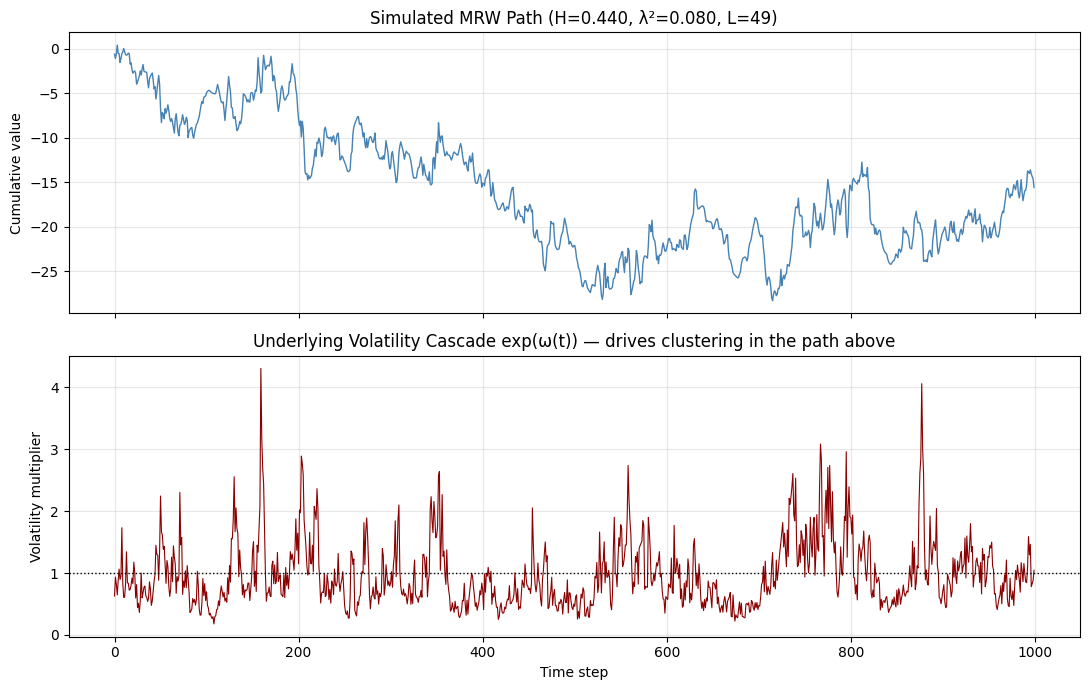

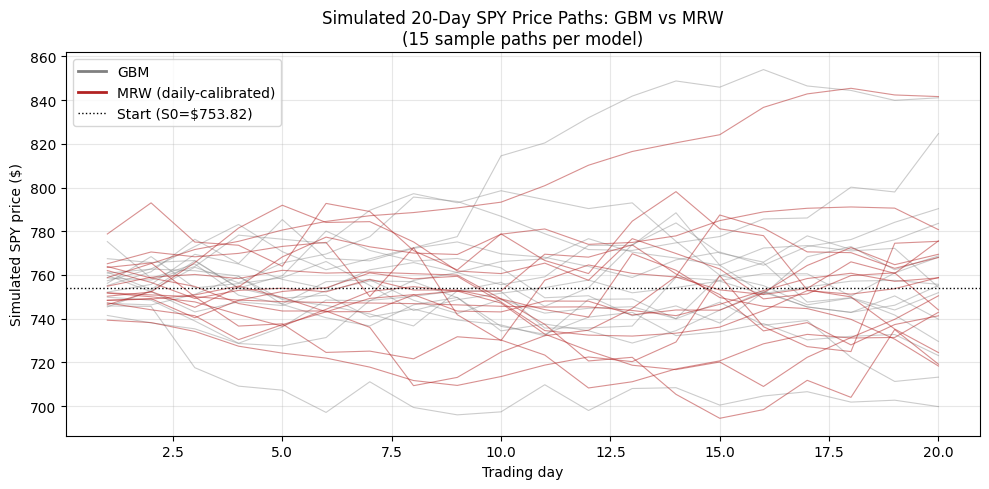

In [23]:
S0 = spy_daily['close'].iloc[-1]  # last actual SPY price

# --- Figure 1: illustrative long path, showing the cascade driving volatility clustering ---
N_illustrate = 1000
gamma_illust = cascade_covariance_row(N_illustrate, L=49, lambda2=0.080)
omega_illust = sample_gaussian_field(N_illustrate, gamma_illust, seed=42) - gamma_illust[0]/2
vol_factor = np.exp(omega_illust)  # this is the time-varying volatility multiplier

X_illust = simulate_subordinated_mrw(N_illustrate, H=0.440, lambda2=0.080, L=49, seed=42)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

axes[0].plot(X_illust[1:], color='steelblue', linewidth=1)
axes[0].set_title('Simulated MRW Path (H=0.440, λ²=0.080, L=49)')
axes[0].set_ylabel('Cumulative value')
axes[0].grid(alpha=0.3)

axes[1].plot(vol_factor, color='darkred', linewidth=0.8)
axes[1].axhline(1.0, color='black', linestyle=':', linewidth=1)
axes[1].set_title('Underlying Volatility Cascade exp(ω(t)) — drives clustering in the path above')
axes[1].set_xlabel('Time step')
axes[1].set_ylabel('Volatility multiplier')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('mrw_illustration.png', dpi=150)
plt.show()

# --- Figure 2: calibrated 20-day price paths, MRW vs GBM ---
fig, ax = plt.subplots(figsize=(10, 5))
n_sample_paths = 15

for i in range(n_sample_paths):
    price_path = S0 * np.exp(gbm_paths[i, :])
    ax.plot(range(1, N_DAYS+1), price_path, color='gray', alpha=0.4, linewidth=0.8)

for i in range(n_sample_paths):
    price_path = S0 * np.exp(mrw_daily_paths[i, :])
    ax.plot(range(1, N_DAYS+1), price_path, color='firebrick', alpha=0.5, linewidth=0.8)

ax.plot([], [], color='gray', label='GBM', linewidth=2)
ax.plot([], [], color='firebrick', label='MRW (daily-calibrated)', linewidth=2)
ax.axhline(S0, color='black', linestyle=':', linewidth=1, label=f'Start (S0=${S0:.2f})')

ax.set_title(f'Simulated 20-Day SPY Price Paths: GBM vs MRW\n({n_sample_paths} sample paths per model)')
ax.set_xlabel('Trading day')
ax.set_ylabel('Simulated SPY price ($)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('mrw_vs_gbm_paths.png', dpi=150)
plt.show()

In [24]:
def compute_cvar(log_returns_horizon, confidence):
    var_threshold = np.percentile(log_returns_horizon, (1 - confidence) * 100)
    tail_losses = log_returns_horizon[log_returns_horizon <= var_threshold]
    return -tail_losses.mean()

def empirical_cvar(log_price, horizon, confidence):
    returns_h = log_price.diff(horizon).dropna().values
    return compute_cvar(returns_h, confidence)

HORIZONS = [1, 10, 20]
CONFIDENCE_LEVELS = [0.95, 0.99]

results = []
for horizon in HORIZONS:
    for confidence in CONFIDENCE_LEVELS:
        row = {'horizon': horizon, 'confidence': confidence}
        row['GBM'] = compute_cvar(gbm_paths[:, horizon-1], confidence)
        row['MRW (daily)'] = compute_cvar(mrw_daily_paths[:, horizon-1], confidence)
        row['Empirical'] = empirical_cvar(spy_daily['log_price'], horizon, confidence)
        results.append(row)

cvar_mrw_table = pd.DataFrame(results)
print(cvar_mrw_table.to_string(index=False))

# --- Gap-to-empirical, same diagnostic as before ---
cvar_mrw_table['gap_GBM'] = cvar_mrw_table['GBM'] - cvar_mrw_table['Empirical']
cvar_mrw_table['gap_MRW'] = cvar_mrw_table['MRW (daily)'] - cvar_mrw_table['Empirical']
print("\n--- Gap to Empirical (negative = undershoot) ---")
print(cvar_mrw_table[['horizon','confidence','gap_GBM','gap_MRW']].to_string(index=False))

 horizon  confidence      GBM  MRW (daily)  Empirical
       1        0.95 0.024248     0.026242   0.029552
       1        0.99 0.032003     0.037553   0.052304
      10        0.95 0.073956     0.073367   0.084931
      10        0.99 0.095451     0.100767   0.156182
      20        0.95 0.103289     0.096326   0.116983
      20        0.99 0.136517     0.133476   0.222425

--- Gap to Empirical (negative = undershoot) ---
 horizon  confidence   gap_GBM   gap_MRW
       1        0.95 -0.005304 -0.003310
       1        0.99 -0.020301 -0.014751
      10        0.95 -0.010975 -0.011565
      10        0.99 -0.060731 -0.055415
      20        0.95 -0.013694 -0.020657
      20        0.99 -0.085908 -0.088949


 horizon  confidence      GBM  MRW (daily)  Empirical
       1        0.95 1.000000     1.000000   1.000000
       1        0.99 1.000000     1.000000   1.000000
      10        0.95 3.049953     2.795768   2.873961
      10        0.99 2.982538     2.683348   2.986057
      20        0.95 4.259640     3.670667   3.958534
      20        0.99 4.265728     3.554351   4.252559


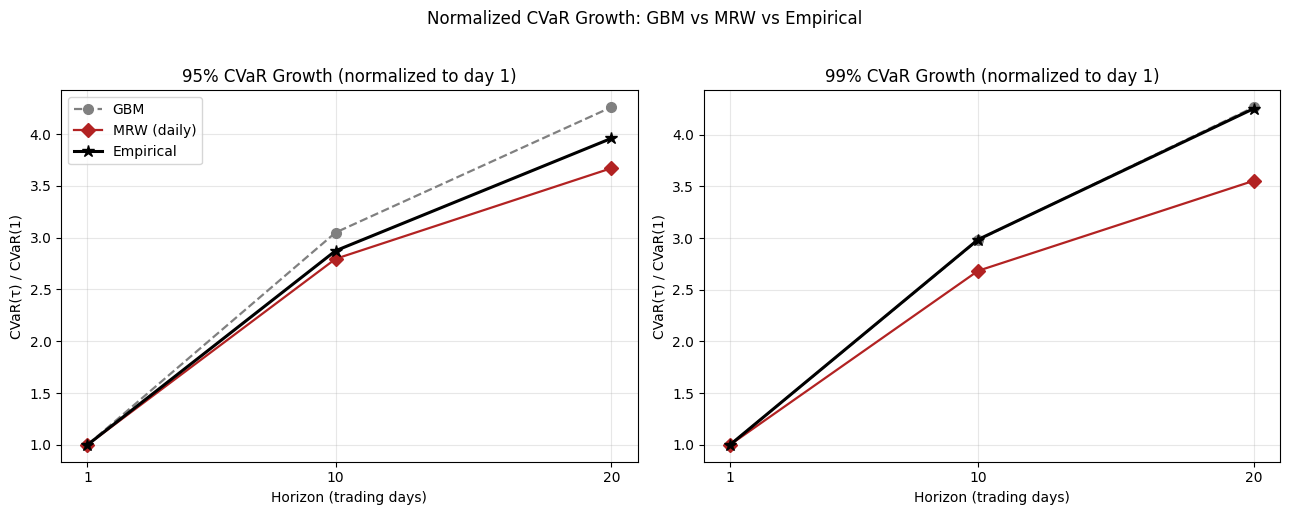

In [25]:
normalized_mrw = cvar_mrw_table.copy()
for col in ['GBM', 'MRW (daily)', 'Empirical']:
    for conf in CONFIDENCE_LEVELS:
        base = normalized_mrw.loc[(normalized_mrw['horizon']==1) & (normalized_mrw['confidence']==conf), col].values[0]
        mask = normalized_mrw['confidence'] == conf
        normalized_mrw.loc[mask, col] = normalized_mrw.loc[mask, col] / base

print(normalized_mrw[['horizon','confidence','GBM','MRW (daily)','Empirical']].to_string(index=False))

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = {'GBM': 'gray', 'MRW (daily)': 'firebrick', 'Empirical': 'black'}
styles = {'GBM': '--', 'MRW (daily)': '-', 'Empirical': '-'}
markers = {'GBM': 'o', 'MRW (daily)': 'D', 'Empirical': '*'}

for ax, conf in zip(axes, CONFIDENCE_LEVELS):
    subset = normalized_mrw[normalized_mrw['confidence'] == conf]
    for model in colors:
        ax.plot(subset['horizon'], subset[model], color=colors[model], linestyle=styles[model],
                marker=markers[model], markersize=9 if model=='Empirical' else 7,
                linewidth=2.2 if model=='Empirical' else 1.6, label=model)
    ax.set_title(f'{int(conf*100)}% CVaR Growth (normalized to day 1)')
    ax.set_xlabel('Horizon (trading days)')
    ax.set_ylabel('CVaR(τ) / CVaR(1)')
    ax.set_xticks(HORIZONS)
    ax.grid(alpha=0.3)

axes[0].legend(loc='upper left')
plt.suptitle('Normalized CVaR Growth: GBM vs MRW vs Empirical', y=1.02)
plt.tight_layout()
plt.savefig('mrw_cvar_normalized.png', dpi=150)
plt.show()

In [27]:
BARS_PER_DAY = 26
L_intraday = 27
H_intraday_fit = 0.460
lambda2_intraday_fit = 0.110

# --- Calibration: bar-level mu, sigma from REAL intraday returns (overnight gaps excluded) ---
mu_bar = spy_intraday_clean_returns.mean()
sigma_bar = spy_intraday_clean_returns.std()
print(f"Bar-level mu: {mu_bar:.7f}, sigma: {sigma_bar:.6f}")

def simulate_mrw_intraday_paths(n_paths, n_bars, H_fit, lambda2_fit, L, mu_target, sigma_target,
                                  seasonal_profile, bars_per_day=26, seed_offset=0):
    """
    Simulates intraday MRW paths, reintroducing the seasonal (time-of-day) volatility
    pattern that was removed for calibration -- real price paths DO have this pattern.
    """
    raw_paths = np.zeros((n_paths, n_bars))
    seasonal_array = np.array([seasonal_profile.get(i % bars_per_day, 1.0) for i in range(n_bars)])

    for i in range(n_paths):
        X = simulate_subordinated_mrw(n_bars, H_fit, lambda2_fit, L, seed=seed_offset + i)
        increments = np.diff(X)  # bar-level increments (length n_bars - 1)
        increments = np.concatenate([[X[1]], increments])  # pad to length n_bars
        increments = increments * seasonal_array  # reintroduce time-of-day volatility pattern
        raw_paths[i, :] = np.cumsum(increments)

    raw_day1_std = raw_paths[:, bars_per_day-1].std()  # std at 1-day (26-bar) mark
    # target: sigma of a 1-day AGGREGATE, i.e. sqrt(26)*sigma_bar roughly, but let's match empirically
    target_1day_std = spy_intraday_clean_returns.groupby(
        spy_intraday.loc[spy_intraday_clean_returns.index, :].index.date
    ).sum().std() if False else np.sqrt(bars_per_day) * sigma_target  # simple scaling approx

    scale_factor = target_1day_std / raw_day1_std
    scaled_paths = raw_paths * scale_factor
    drift = mu_target * np.arange(1, n_bars + 1)
    scaled_paths = scaled_paths + drift
    return scaled_paths

N_BARS = 20 * BARS_PER_DAY  # 520 bars = 20 trading days
N_PATHS_INTRADAY = 5000     # start smaller than 50,000 -- each path is more expensive to generate

def simulate_mrw_intraday_paths(n_paths, n_bars, H_fit, lambda2_fit, L, mu_target, sigma_target,
                                  seasonal_profile, bars_per_day=26, seed_offset=0):
    raw_paths = np.zeros((n_paths, n_bars))
    seasonal_array = np.array([seasonal_profile.get(i % bars_per_day, 1.0) for i in range(n_bars)])

    for i in range(n_paths):
        X = simulate_subordinated_mrw(n_bars, H_fit, lambda2_fit, L, seed=seed_offset + i)
        increments = np.diff(X)  # length n_bars -- FIX: no extra padding needed, X already has n_bars+1 points
        increments = increments * seasonal_array
        raw_paths[i, :] = np.cumsum(increments)

    raw_day1_std = raw_paths[:, bars_per_day-1].std()
    target_1day_std = np.sqrt(bars_per_day) * sigma_target
    scale_factor = target_1day_std / raw_day1_std
    scaled_paths = raw_paths * scale_factor
    drift = mu_target * np.arange(1, n_bars + 1)
    scaled_paths = scaled_paths + drift
    return scaled_paths

N_BARS = 20 * BARS_PER_DAY
N_PATHS_INTRADAY = 5000

mrw_intraday_paths = simulate_mrw_intraday_paths(
    N_PATHS_INTRADAY, N_BARS, H_intraday_fit, lambda2_intraday_fit, L_intraday,
    mu_bar, sigma_bar, seasonal_profile, bars_per_day=BARS_PER_DAY, seed_offset=0
)

print(f"Intraday MRW paths generated: {mrw_intraday_paths.shape}")
day1_idx = BARS_PER_DAY - 1
print(f"1-day mark: mean={mrw_intraday_paths[:,day1_idx].mean():.6f}, std={mrw_intraday_paths[:,day1_idx].std():.6f}")
print(f"Target (sqrt(26)*sigma_bar): {np.sqrt(BARS_PER_DAY)*sigma_bar:.6f}")

print(f"\nIntraday MRW paths generated: {mrw_intraday_paths.shape}")
day1_idx = BARS_PER_DAY - 1
print(f"1-day mark: mean={mrw_intraday_paths[:,day1_idx].mean():.6f}, std={mrw_intraday_paths[:,day1_idx].std():.6f}")
print(f"Target (sqrt(26)*sigma_bar): {np.sqrt(BARS_PER_DAY)*sigma_bar:.6f}")

Bar-level mu: 0.0000089, sigma: 0.001340
Intraday MRW paths generated: (5000, 520)
1-day mark: mean=0.000132, std=0.006831
Target (sqrt(26)*sigma_bar): 0.006831

Intraday MRW paths generated: (5000, 520)
1-day mark: mean=0.000132, std=0.006831
Target (sqrt(26)*sigma_bar): 0.006831


In [28]:
# --- Bar indices corresponding to 1, 10, 20 trading days ---
bar_marks = {1: BARS_PER_DAY-1, 10: 10*BARS_PER_DAY-1, 20: 20*BARS_PER_DAY-1}

results_intraday = []
for horizon in HORIZONS:
    for confidence in CONFIDENCE_LEVELS:
        row = {'horizon': horizon, 'confidence': confidence}
        row['GBM'] = compute_cvar(gbm_paths[:, horizon-1], confidence)
        row['MRW (daily)'] = compute_cvar(mrw_daily_paths[:, horizon-1], confidence)
        row['MRW (intraday)'] = compute_cvar(mrw_intraday_paths[:, bar_marks[horizon]], confidence)
        row['Empirical'] = empirical_cvar(spy_daily['log_price'], horizon, confidence)
        results_intraday.append(row)

cvar_full_table = pd.DataFrame(results_intraday)
print(cvar_full_table.to_string(index=False))

cvar_full_table['gap_GBM'] = cvar_full_table['GBM'] - cvar_full_table['Empirical']
cvar_full_table['gap_MRW_daily'] = cvar_full_table['MRW (daily)'] - cvar_full_table['Empirical']
cvar_full_table['gap_MRW_intraday'] = cvar_full_table['MRW (intraday)'] - cvar_full_table['Empirical']
print("\n--- Gaps to Empirical ---")
print(cvar_full_table[['horizon','confidence','gap_GBM','gap_MRW_daily','gap_MRW_intraday']].to_string(index=False))

 horizon  confidence      GBM  MRW (daily)  MRW (intraday)  Empirical
       1        0.95 0.024248     0.026242        0.014447   0.029552
       1        0.99 0.032003     0.037553        0.020119   0.052304
      10        0.95 0.073956     0.073367        0.038533   0.084931
      10        0.99 0.095451     0.100767        0.051882   0.156182
      20        0.95 0.103289     0.096326        0.052177   0.116983
      20        0.99 0.136517     0.133476        0.067415   0.222425

--- Gaps to Empirical ---
 horizon  confidence   gap_GBM  gap_MRW_daily  gap_MRW_intraday
       1        0.95 -0.005304      -0.003310         -0.015105
       1        0.99 -0.020301      -0.014751         -0.032185
      10        0.95 -0.010975      -0.011565         -0.046398
      10        0.99 -0.060731      -0.055415         -0.104300
      20        0.95 -0.013694      -0.020657         -0.064806
      20        0.99 -0.085908      -0.088949         -0.155010


In [29]:
# --- Step 1: per-day open-to-close log return (sum of within-day 15-min returns) ---
daily_oc_returns = spy_intraday_clean_returns.groupby(spy_intraday_clean_returns.index.date).sum()
daily_oc_returns.index = pd.to_datetime(daily_oc_returns.index)
daily_oc_returns = daily_oc_returns.sort_index()

print(f"Open-to-close daily returns: {len(daily_oc_returns)} days")
print(daily_oc_returns.describe())

# --- Consistency check: does this recover ~32.7% of close-to-close daily variance? ---
sigma_oc = daily_oc_returns.std()
sigma_cc_bounded = spy_daily_bounded['log_return'].std()  # close-to-close, SAME 178-day window
implied_intraday_share = (sigma_oc**2) / (sigma_cc_bounded**2) * 100
print(f"\nOpen-to-close sigma: {sigma_oc:.6f}")
print(f"Close-to-close sigma (same window): {sigma_cc_bounded:.6f}")
print(f"Implied intraday variance share: {implied_intraday_share:.1f}% (earlier estimate: 32.7%)")

# --- Step 2: N-day cumulative intraday-only returns via overlapping rolling sums ---
def empirical_cvar_intraday_only(daily_oc_returns, horizon, confidence):
    rolling_sum = daily_oc_returns.rolling(window=horizon).sum().dropna()
    return compute_cvar(rolling_sum.values, confidence), len(rolling_sum)

# --- Step 3: Build the comparison table: MRW-intraday vs fair intraday-only empirical ---
results_fair = []
for horizon in HORIZONS:
    for confidence in CONFIDENCE_LEVELS:
        cvar_emp_intraday, n_windows = empirical_cvar_intraday_only(daily_oc_returns, horizon, confidence)
        cvar_mrw_id = compute_cvar(mrw_intraday_paths[:, bar_marks[horizon]], confidence)
        results_fair.append({
            'horizon': horizon, 'confidence': confidence,
            'MRW (intraday)': cvar_mrw_id,
            'Empirical (open-to-close only)': cvar_emp_intraday,
            'n_windows': n_windows
        })

cvar_fair_table = pd.DataFrame(results_fair)
print("\n=== Fair, like-for-like comparison (intraday-only scope) ===")
print(cvar_fair_table.to_string(index=False))

Open-to-close daily returns: 178 days
count    178.000000
mean       0.000222
std        0.006614
min       -0.031854
25%       -0.002771
50%        0.000889
75%        0.003793
max        0.021022
Name: log_return, dtype: float64

Open-to-close sigma: 0.006614
Close-to-close sigma (same window): 0.008463
Implied intraday variance share: 61.1% (earlier estimate: 32.7%)

=== Fair, like-for-like comparison (intraday-only scope) ===
 horizon  confidence  MRW (intraday)  Empirical (open-to-close only)  n_windows
       1        0.95        0.014447                        0.016224        178
       1        0.99        0.020119                        0.025263        178
      10        0.95        0.038533                        0.045669        169
      10        0.99        0.051882                        0.054494        169
      20        0.95        0.052177                        0.040579        159
      20        0.99        0.067415                        0.043797        159


In [30]:
def simulate_fbm_price_paths(n_paths, n_days, H, mu, sigma, seed=42):
    log_price_paths = np.zeros((n_paths, n_days))
    for i in range(n_paths):
        fgn = davies_harte_fgn(n_days, H, seed=seed + i)
        daily_returns = mu + sigma * fgn
        log_price_paths[i, :] = np.cumsum(daily_returns)
    return log_price_paths

H_ESTIMATES = {'structure_functions': 0.468, 'dfa': 0.486, 'rs': 0.534}

fbm_paths = {}
for name, H in H_ESTIMATES.items():
    print(f"Simulating fBm (H={H}, {name})...")
    fbm_paths[name] = simulate_fbm_price_paths(N_PATHS, N_DAYS, H, mu_daily, sigma_daily, seed=42)

print("Done.")

Simulating fBm (H=0.468, structure_functions)...
Simulating fBm (H=0.486, dfa)...
Simulating fBm (H=0.534, rs)...
Done.


In [31]:
results_full = []
for horizon in HORIZONS:
    for confidence in CONFIDENCE_LEVELS:
        row = {'horizon': horizon, 'confidence': confidence}
        row['GBM'] = compute_cvar(gbm_paths[:, horizon-1], confidence)
        row['fBm (SF, H=0.468)'] = compute_cvar(fbm_paths['structure_functions'][:, horizon-1], confidence)
        row['fBm (DFA, H=0.486)'] = compute_cvar(fbm_paths['dfa'][:, horizon-1], confidence)
        row['fBm (RS, H=0.534)'] = compute_cvar(fbm_paths['rs'][:, horizon-1], confidence)
        row['MRW (daily)'] = compute_cvar(mrw_daily_paths[:, horizon-1], confidence)
        row['MRW (intraday)'] = compute_cvar(mrw_intraday_paths[:, bar_marks[horizon]], confidence)
        row['Empirical (close-to-close)'] = empirical_cvar(spy_daily['log_price'], horizon, confidence)
        results_full.append(row)

cvar_master_table = pd.DataFrame(results_full)
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 10)
print(cvar_master_table.to_string(index=False))

 horizon  confidence      GBM  fBm (SF, H=0.468)  fBm (DFA, H=0.486)  fBm (RS, H=0.534)  MRW (daily)  MRW (intraday)  Empirical (close-to-close)
       1        0.95 0.024248           0.024071            0.024069           0.024058     0.026242        0.014447                    0.029552
       1        0.99 0.032003           0.031132            0.031119           0.031075     0.037553        0.020119                    0.052304
      10        0.95 0.073956           0.068368            0.071420           0.080176     0.073367        0.038533                    0.084931
      10        0.99 0.095451           0.090527            0.094509           0.105934     0.100767        0.051882                    0.156182
      20        0.95 0.103289           0.091416            0.096944           0.113236     0.096326        0.052177                    0.116983
      20        0.99 0.136517           0.121456            0.128703           0.149997     0.133476        0.067415              

In [34]:

# Fix: drop the NaN before bootstrapping



def bootstrap_simulated_cvar(paths_column, confidence, n_boot=500, seed=0):
    """Resamples simulated path outcomes with replacement, recomputes CVaR each time."""
    rng = np.random.default_rng(seed)
    n = len(paths_column)
    cvars = np.zeros(n_boot)
    for b in range(n_boot):
        resampled = rng.choice(paths_column, size=n, replace=True)
        cvars[b] = compute_cvar(resampled, confidence)
    return cvars

def moving_block_bootstrap_returns(returns, block_length, total_length, seed=None):
    """Resamples contiguous blocks of the return series (preserves autocorrelation)."""
    rng = np.random.default_rng(seed)
    n = len(returns)
    n_blocks = int(np.ceil(total_length / block_length))
    blocks = [returns[start:start+block_length] 
              for start in rng.integers(0, n - block_length, size=n_blocks)]
    return np.concatenate(blocks)[:total_length]

def bootstrap_empirical_cvar(returns, horizon, confidence, n_boot=500, seed=0):
    """Block-bootstrap CVaR for the empirical series, block length scales with horizon."""
    block_length = max(2 * horizon, 20)
    total_length = len(returns)
    cvars = np.zeros(n_boot)
    for b in range(n_boot):
        synth_returns = moving_block_bootstrap_returns(returns.values, block_length, total_length, seed=seed+b)
        synth_log_price = np.cumsum(synth_returns)
        horizon_returns = synth_log_price[horizon:] - synth_log_price[:-horizon]
        cvars[b] = compute_cvar(horizon_returns, confidence)
    return cvars

# --- Run for day-1, both confidence levels: your headline result ---
N_BOOT = 500
bootstrap_results = {}

for confidence in CONFIDENCE_LEVELS:
    horizon = 1
    gbm_boot = bootstrap_simulated_cvar(gbm_paths[:, horizon-1], confidence, N_BOOT, seed=1)
    mrw_boot = bootstrap_simulated_cvar(mrw_daily_paths[:, horizon-1], confidence, N_BOOT, seed=2)
    emp_boot = bootstrap_empirical_cvar(spy_daily['log_return'].dropna(), horizon, confidence, N_BOOT, seed=3)  # <-- .dropna() added

    gap_gbm_boot = gbm_boot - emp_boot
    gap_mrw_boot = mrw_boot - emp_boot
    mrw_closer_pct = np.mean(np.abs(gap_mrw_boot) < np.abs(gap_gbm_boot)) * 100

    print(f"--- Day 1, {int(confidence*100)}% CVaR ---")
    print(f"GBM CVaR:  {gbm_boot.mean():.5f}  (95% CI: [{np.percentile(gbm_boot,2.5):.5f}, {np.percentile(gbm_boot,97.5):.5f}])")
    print(f"MRW CVaR:  {mrw_boot.mean():.5f}  (95% CI: [{np.percentile(mrw_boot,2.5):.5f}, {np.percentile(mrw_boot,97.5):.5f}])")
    print(f"Emp CVaR:  {emp_boot.mean():.5f}  (95% CI: [{np.percentile(emp_boot,2.5):.5f}, {np.percentile(emp_boot,97.5):.5f}])")
    print(f"MRW closer to Empirical than GBM in {mrw_closer_pct:.1f}% of bootstrap draws\n")


--- Day 1, 95% CVaR ---
GBM CVaR:  0.02424  (95% CI: [0.02399, 0.02451])
MRW CVaR:  0.02623  (95% CI: [0.02589, 0.02659])
Emp CVaR:  0.02958  (95% CI: [0.02536, 0.03471])
MRW closer to Empirical than GBM in 97.8% of bootstrap draws

--- Day 1, 99% CVaR ---
GBM CVaR:  0.03199  (95% CI: [0.03147, 0.03252])
MRW CVaR:  0.03751  (95% CI: [0.03669, 0.03833])
Emp CVaR:  0.05184  (95% CI: [0.04058, 0.06439])
MRW closer to Empirical than GBM in 100.0% of bootstrap draws

